# Day 05 – Phase 2: PCA on Gene Expression Cancer RNA-Seq

**Goal:** apply PCA to a high-dimensional gene expression dataset, build a Scree Plot, find the number of components needed for 85/90/95% explained variance, compare Logistic Regression before/after PCA, and inspect PCA loadings.

Put the Kaggle files here:

```text
Tag_05_PCA_Dimensionsreduktion/data/gene_expression/data.csv
Tag_05_PCA_Dimensionsreduktion/data/gene_expression/labels.csv
```

## Dataset Validation
Run this cell to verify that your datasets are present and correctly formatted.

In [1]:
# --- DATASET VALIDATION ---
import os
import pandas as pd

def validate_dataset(filepath, expected_columns=None, avoid_columns=None):
    if not os.path.exists(filepath):
        print(f'❌ ERROR: Dataset not found at {filepath}')
        return False
    try:
        df = pd.read_csv(filepath, nrows=5)
        print(f'✅ SUCCESS: Dataset found at {filepath} (Columns: {df.shape[1]})')
        if expected_columns:
            missing = [c for c in expected_columns if c not in df.columns]
            if missing:
                print(f'⚠️ WARNING: Missing expected columns: {missing}')
                return False
        if avoid_columns:
            forbidden = [c for c in avoid_columns if c in df.columns]
            if forbidden:
                print(f'❌ ERROR: Found forbidden columns {forbidden}. Wrong dataset!')
                return False
        return True
    except Exception as e:
        print(f'❌ ERROR: Could not read dataset: {e}')
        return False

print('Validating PCA Datasets...')
validate_dataset('../data/winequality-red.csv')
validate_dataset('../data/gene_expression/data.csv')
validate_dataset('../data/gene_expression/labels.csv')

Validating PCA Datasets...
✅ SUCCESS: Dataset found at ../data/winequality-red.csv (Columns: 1)


✅ SUCCESS: Dataset found at ../data/gene_expression/data.csv (Columns: 20532)
✅ SUCCESS: Dataset found at ../data/gene_expression/labels.csv (Columns: 2)


True

In [2]:
# ============================================================
# Cell 1 - Imports and Folder Setup
# ============================================================

import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

DAY04_DIR = r"C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_04_Outlier_Anomaly"
AUFGABE_DIR = os.path.dirname(DAY04_DIR)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))

DATA_DIR = os.path.join(BASE_DIR, "data")
GENE_DATA_DIR = os.path.join(DATA_DIR, "gene_expression")
OUTPUT_DIR = os.path.join(BASE_DIR, "output")
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
TABLES_DIR = os.path.join(OUTPUT_DIR, "tables")
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")
REPORTS_DIR = os.path.join(OUTPUT_DIR, "reports")
NOTEBOOKS_DIR = os.path.join(BASE_DIR, "notebooks")
PHASE2_TABLES_DIR = os.path.join(TABLES_DIR, "phase2_gene_expression")
PHASE2_FIGURES_DIR = os.path.join(FIGURES_DIR, "phase2_gene_expression")

for folder in [BASE_DIR, DATA_DIR, GENE_DATA_DIR, OUTPUT_DIR, FIGURES_DIR, TABLES_DIR,
               MODELS_DIR, REPORTS_DIR, NOTEBOOKS_DIR, PHASE2_TABLES_DIR, PHASE2_FIGURES_DIR]:
    os.makedirs(folder, exist_ok=True)

print("✅ Folder structure is ready.")
print("GENE_DATA_DIR:", GENE_DATA_DIR)
print("PHASE2_TABLES_DIR:", PHASE2_TABLES_DIR)
print("PHASE2_FIGURES_DIR:", PHASE2_FIGURES_DIR)

✅ Folder structure is ready.
GENE_DATA_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\data\gene_expression
PHASE2_TABLES_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\output\tables\phase2_gene_expression
PHASE2_FIGURES_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\output\figures\phase2_gene_expression


In [3]:
# ============================================================
# Cell 2 - Load Gene Expression Dataset
# ============================================================

data_file = os.path.join(GENE_DATA_DIR, "data.csv")
labels_file = os.path.join(GENE_DATA_DIR, "labels.csv")

print("Looking for data.csv and labels.csv in:")
print(GENE_DATA_DIR)

if not os.path.exists(data_file) or not os.path.exists(labels_file):
    print("\n❌ data.csv or labels.csv was not found.")
    print("Download the Gene Expression Cancer RNA-Seq Kaggle dataset and put these files here:")
    print(" -", data_file)
    print(" -", labels_file)
    raise FileNotFoundError("Missing data.csv and/or labels.csv")

data_raw = pd.read_csv(data_file)
labels_raw = pd.read_csv(labels_file)

print("✅ Files loaded.")
print("data_raw shape:", data_raw.shape)
print("labels_raw shape:", labels_raw.shape)
display(data_raw.head())
display(labels_raw.head())

Looking for data.csv and labels.csv in:
C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\data\gene_expression


✅ Files loaded.
data_raw shape: (801, 20532)
labels_raw shape: (801, 2)


,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


,Unnamed: 0,Class
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD
3,sample_3,PRAD
4,sample_4,BRCA


In [4]:
# ============================================================
# Cell 3 - Clean and Align Data with Labels
# ============================================================

data_df = data_raw.copy()
labels_df = labels_raw.copy()

data_df.columns = data_df.columns.astype(str).str.strip()
labels_df.columns = labels_df.columns.astype(str).str.strip()

first_data_col = data_df.columns[0]
if first_data_col.lower().startswith("unnamed") or first_data_col.lower() in ["sample", "sample_id", "id"]:
    data_df = data_df.set_index(first_data_col)

first_label_col = labels_df.columns[0]
if first_label_col.lower().startswith("unnamed") or first_label_col.lower() in ["sample", "sample_id", "id"]:
    labels_df = labels_df.set_index(first_label_col)

possible_label_cols = ["Class", "class", "label", "Label", "tumor_type", "Tumor_Type", "type", "Type"]
label_col = next((col for col in possible_label_cols if col in labels_df.columns), labels_df.columns[0])
print("Detected label column:", label_col)

X = data_df.select_dtypes(include=[np.number]).copy()
y = labels_df[label_col].copy()

common_index = X.index.intersection(y.index)
if len(common_index) == len(X) and len(common_index) == len(y):
    X = X.loc[common_index]
    y = y.loc[common_index]
else:
    print("⚠️ Index alignment was not perfect. Falling back to row order.")
    min_len = min(len(X), len(y))
    X = X.iloc[:min_len].copy()
    y = y.iloc[:min_len].copy()

valid_mask = y.notna()
X = X.loc[valid_mask].copy()
y = y.loc[valid_mask].copy()
feature_names = X.columns.tolist()

print("✅ Cleaned dataset is ready.")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of gene features:", len(feature_names))
print("\nClass distribution:")
display(y.value_counts())
display(X.head())

Detected label column: Class
✅ Cleaned dataset is ready.
X shape: (801, 20531)
y shape: (801,)
Number of gene features: 20531

Class distribution:


Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


In [5]:
# ============================================================
# Cell 4 - Basic Data Understanding and Save Tables
# ============================================================

basic_info = pd.DataFrame({
    "item": ["number_of_samples", "number_of_gene_features", "number_of_classes", "missing_values_in_X", "missing_values_in_y"],
    "value": [X.shape[0], X.shape[1], y.nunique(), int(X.isna().sum().sum()), int(y.isna().sum())]
})
class_counts = y.value_counts().reset_index()
class_counts.columns = ["class", "count"]

display(basic_info)
display(class_counts)

basic_info.to_csv(os.path.join(PHASE2_TABLES_DIR, "day05_phase2_gene_basic_info.csv"), index=False)
class_counts.to_csv(os.path.join(PHASE2_TABLES_DIR, "day05_phase2_gene_class_counts.csv"), index=False)
print("✅ Saved basic info and class counts.")

,item,value
0,number_of_samples,801
1,number_of_gene_features,20531
2,number_of_classes,5
3,missing_values_in_X,0
4,missing_values_in_y,0


,class,count
0,BRCA,300
1,KIRC,146
2,LUAD,141
3,PRAD,136
4,COAD,78


✅ Saved basic info and class counts.


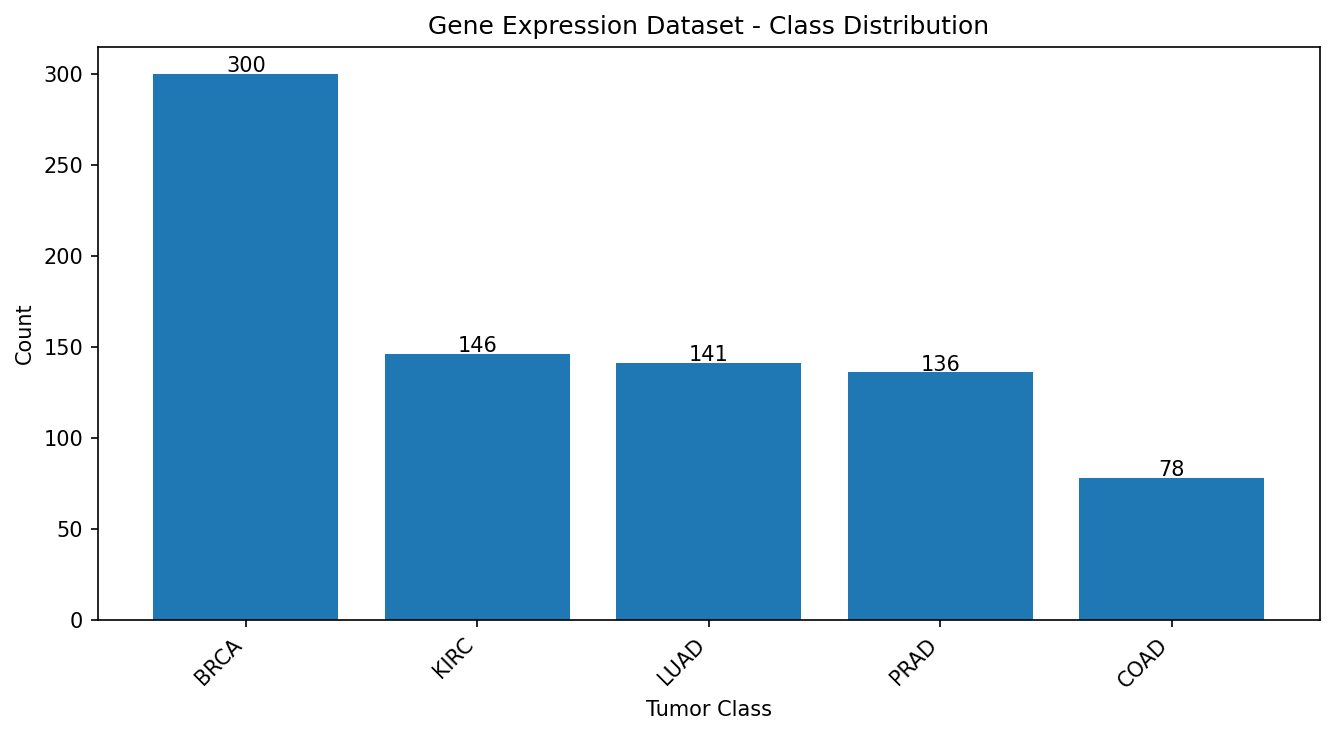

✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\output\figures\phase2_gene_expression\day05_phase2_gene_class_distribution.png


In [6]:
# ============================================================
# Cell 5 - Class Distribution Plot
# ============================================================

plt.figure(figsize=(9, 5), dpi=150)
classes = class_counts["class"].astype(str)
counts = class_counts["count"]
plt.bar(classes, counts)
plt.xlabel("Tumor Class")
plt.ylabel("Count")
plt.title("Gene Expression Dataset - Class Distribution")
plt.xticks(rotation=45, ha="right")
for i, value in enumerate(counts):
    plt.text(i, value + 1, str(value), ha="center")
plt.tight_layout()
class_plot_path = os.path.join(PHASE2_FIGURES_DIR, "day05_phase2_gene_class_distribution.png")
plt.savefig(class_plot_path, dpi=300)
plt.show()
print("✅ Saved:", class_plot_path)

In [7]:
# ============================================================
# Cell 6 - Standardization for PCA Exploration
# ============================================================

scaler_all = StandardScaler()
X_scaled_all = scaler_all.fit_transform(X)
X_scaled_all_df = pd.DataFrame(X_scaled_all, index=X.index, columns=feature_names)

print("Scaled X shape:", X_scaled_all_df.shape)
print("Mean check, first 5 features:")
display(X_scaled_all_df.iloc[:, :5].mean().round(4))
print("Standard deviation check, first 5 features:")
display(X_scaled_all_df.iloc[:, :5].std().round(4))

Scaled X shape: (801, 20531)
Mean check, first 5 features:


gene_0   -0.0
gene_1   -0.0
gene_2    0.0
gene_3    0.0
gene_4   -0.0
dtype: float64

Standard deviation check, first 5 features:


gene_0    1.0006
gene_1    1.0006
gene_2    1.0006
gene_3    1.0006
gene_4    1.0006
dtype: float64

In [8]:
# ============================================================
# Cell 7 - Full PCA for Explained Variance Analysis
# ============================================================

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled_all)
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
n_components_total = len(explained_variance)

n_85 = np.argmax(cumulative_variance >= 0.85) + 1
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Total possible PCA components:", n_components_total)
print("Components needed for 85% variance:", n_85)
print("Components needed for 90% variance:", n_90)
print("Components needed for 95% variance:", n_95)

explained_df = pd.DataFrame({
    "component_number": np.arange(1, n_components_total + 1),
    "explained_variance_ratio": explained_variance,
    "explained_variance_percent": explained_variance * 100,
    "cumulative_variance_ratio": cumulative_variance,
    "cumulative_variance_percent": cumulative_variance * 100
})
display(explained_df.head(20))
explained_path = os.path.join(PHASE2_TABLES_DIR, "day05_phase2_gene_pca_full_explained_variance.csv")
explained_df.to_csv(explained_path, index=False)
print("✅ Saved:", explained_path)

Total possible PCA components: 801
Components needed for 85% variance: 262
Components needed for 90% variance: 373
Components needed for 95% variance: 530


,component_number,explained_variance_ratio,explained_variance_percent,cumulative_variance_ratio,cumulative_variance_percent
0,1,0.105398,10.539781,0.105398,10.539781
1,2,0.087542,8.754232,0.192940,19.294014
2,3,0.078101,7.810081,0.271041,27.104095
3,4,0.051656,5.165647,0.322697,32.269742
4,5,0.040289,4.028932,0.362987,36.298674
5,6,0.029209,2.920881,0.392196,39.219555
6,7,0.023547,2.354735,0.415743,41.574290
7,8,0.021453,2.145299,0.437196,43.719589
8,9,0.016320,1.632001,0.453516,45.351590
9,10,0.012339,1.233899,0.465855,46.585490


✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\output\tables\phase2_gene_expression\day05_phase2_gene_pca_full_explained_variance.csv


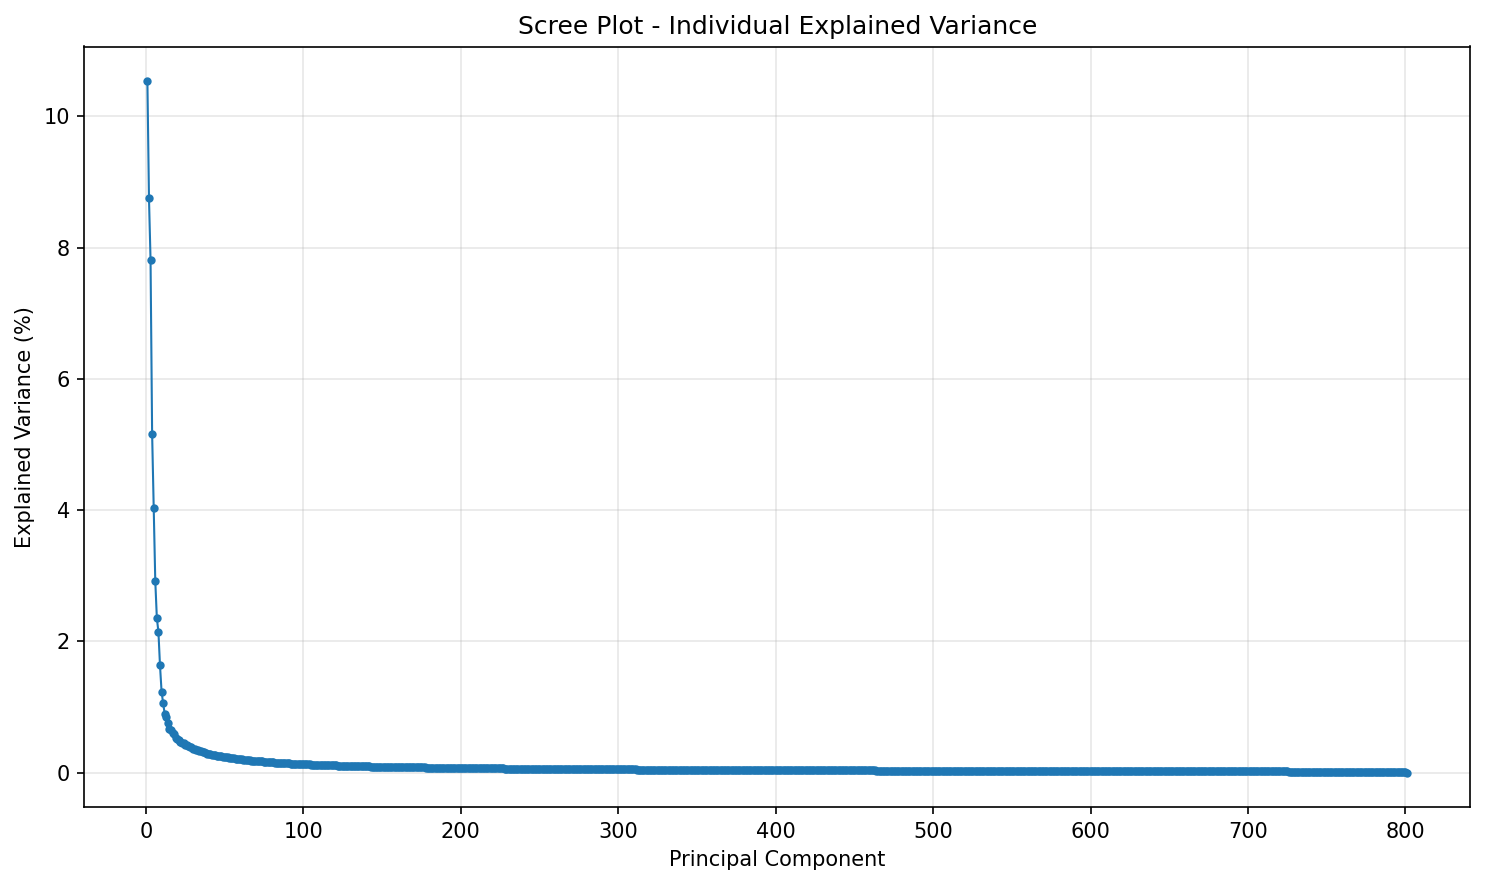

✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\output\figures\phase2_gene_expression\day05_phase2_gene_scree_plot.png


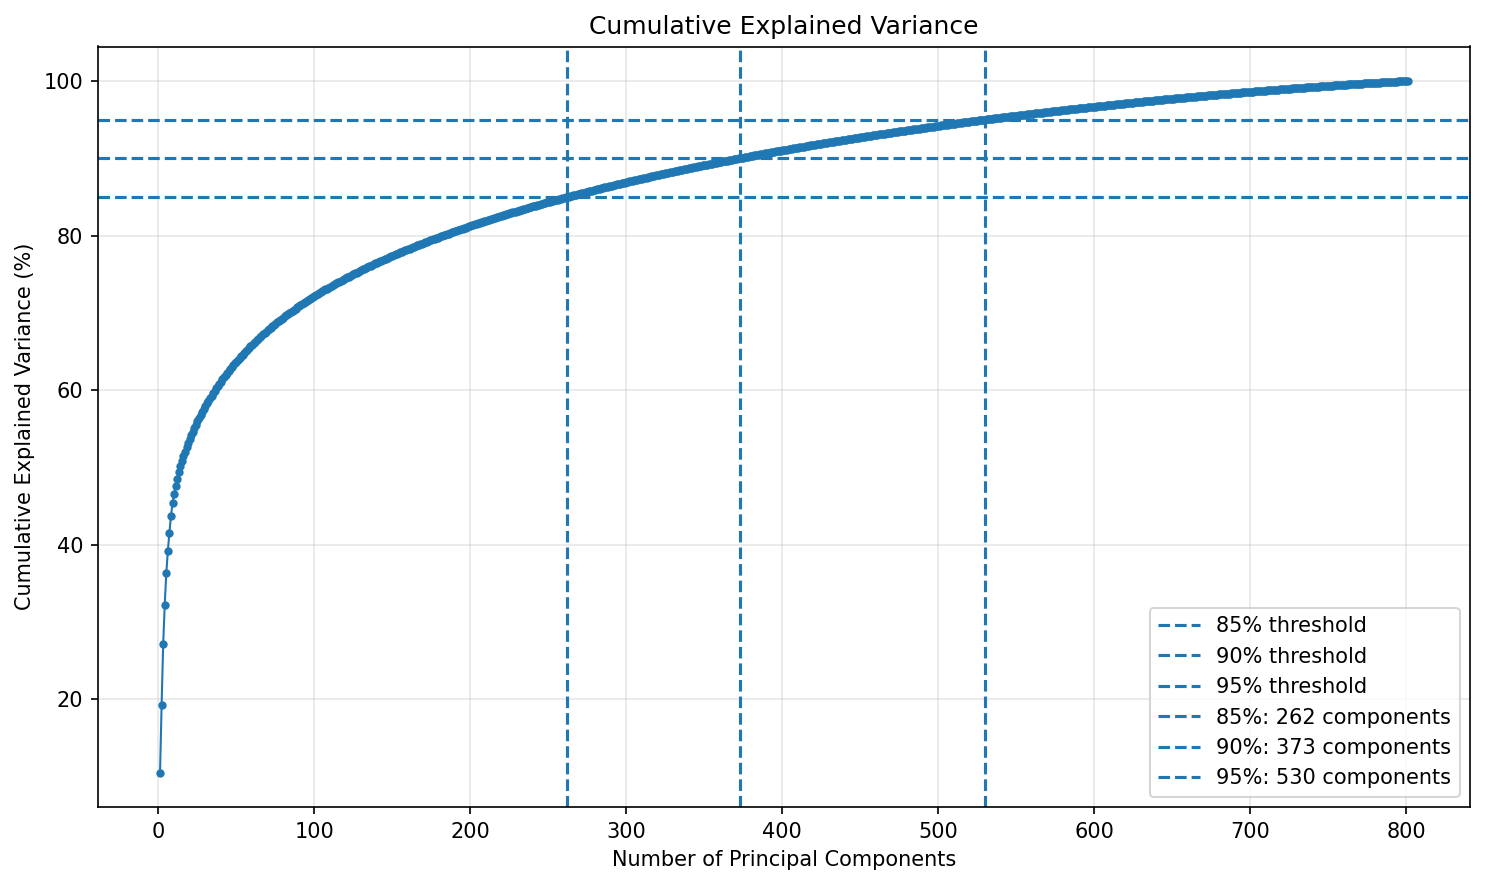

✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\output\figures\phase2_gene_expression\day05_phase2_gene_cumulative_explained_variance.png


In [9]:
# ============================================================
# Cell 8 - Scree Plot and Cumulative Explained Variance Plot
# ============================================================

plt.figure(figsize=(10, 6), dpi=150)
plt.plot(explained_df["component_number"], explained_df["explained_variance_percent"], marker="o", markersize=3, linewidth=1)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot - Individual Explained Variance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
scree_path = os.path.join(PHASE2_FIGURES_DIR, "day05_phase2_gene_scree_plot.png")
plt.savefig(scree_path, dpi=300)
plt.show()
print("✅ Saved:", scree_path)

plt.figure(figsize=(10, 6), dpi=150)
plt.plot(explained_df["component_number"], explained_df["cumulative_variance_percent"], marker="o", markersize=3, linewidth=1)
plt.axhline(85, linestyle="--", label="85% threshold")
plt.axhline(90, linestyle="--", label="90% threshold")
plt.axhline(95, linestyle="--", label="95% threshold")
plt.axvline(n_85, linestyle="--", label=f"85%: {n_85} components")
plt.axvline(n_90, linestyle="--", label=f"90%: {n_90} components")
plt.axvline(n_95, linestyle="--", label=f"95%: {n_95} components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
cum_path = os.path.join(PHASE2_FIGURES_DIR, "day05_phase2_gene_cumulative_explained_variance.png")
plt.savefig(cum_path, dpi=300)
plt.show()
print("✅ Saved:", cum_path)

2D explained variance: [0.10539781 0.08754232]
Total 2D explained variance: 0.19294013819924133


,PC1,PC2,class
0,-57.446987,95.410981,PRAD
1,-16.919430,0.732469,LUAD
2,-70.345219,-19.303326,PRAD
3,-49.161591,-9.227587,PRAD
4,-18.132533,-51.327797,BRCA


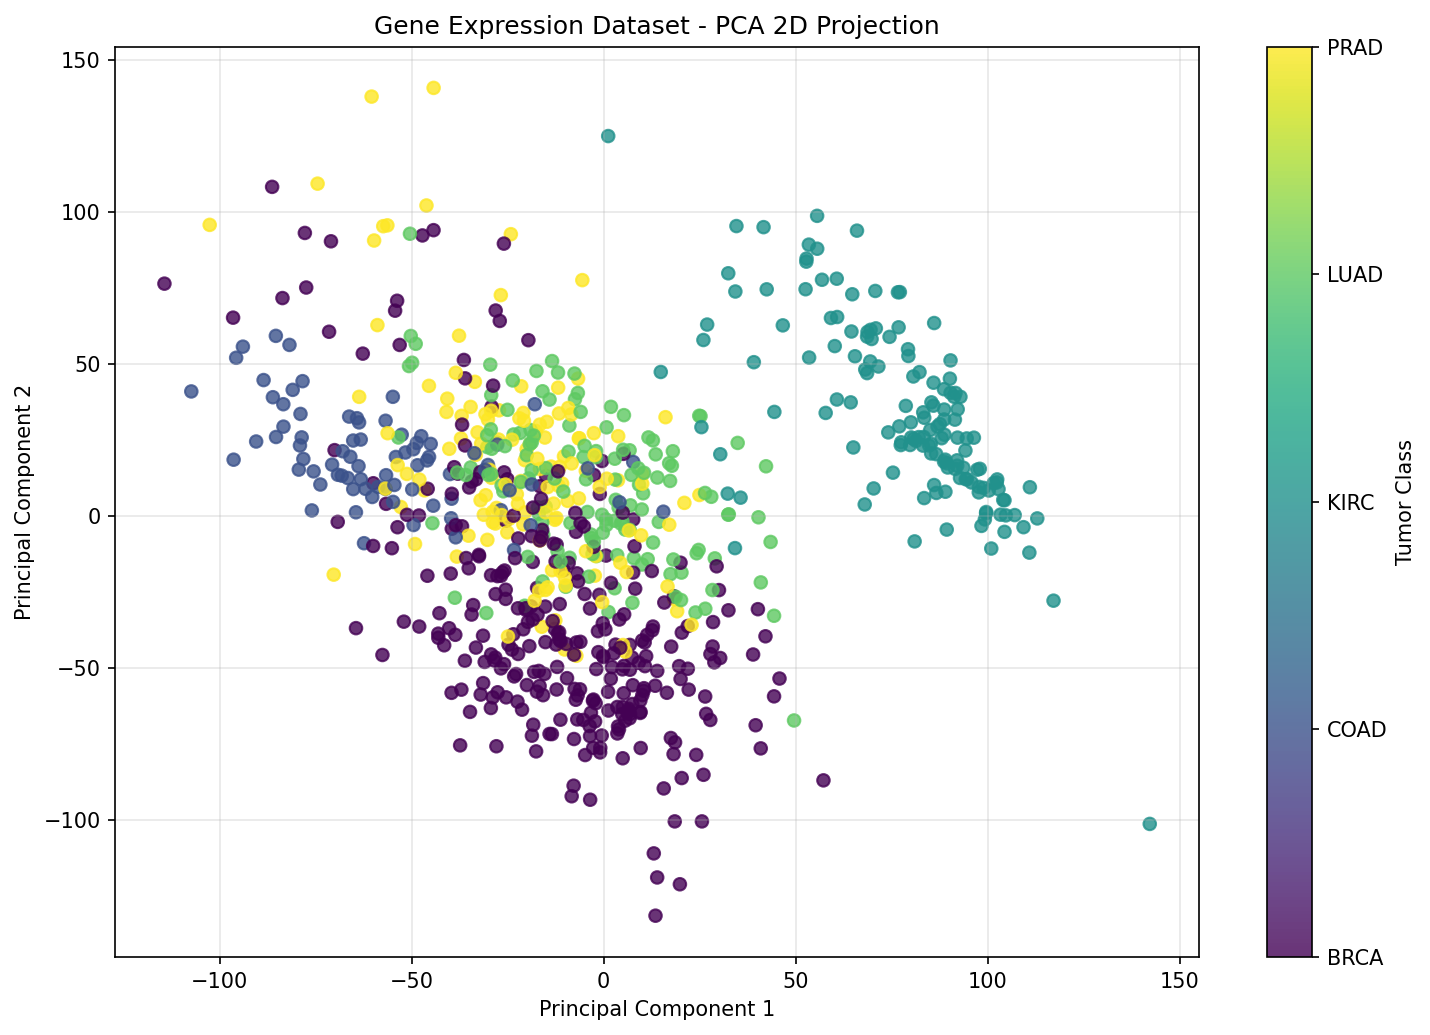

✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\output\figures\phase2_gene_expression\day05_phase2_gene_pca_2d_scatterplot.png


In [10]:
# ============================================================
# Cell 9 - PCA 2D Visualization
# ============================================================

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled_all)
pcdf_2d = pd.DataFrame({"PC1": X_pca_2d[:, 0], "PC2": X_pca_2d[:, 1], "class": y.values})
pcdf_2d_path = os.path.join(PHASE2_TABLES_DIR, "day05_phase2_gene_pca_2d_transformed_data.csv")
pcdf_2d.to_csv(pcdf_2d_path, index=False)

print("2D explained variance:", pca_2d.explained_variance_ratio_)
print("Total 2D explained variance:", pca_2d.explained_variance_ratio_.sum())
display(pcdf_2d.head())

le_plot = LabelEncoder()
class_codes = le_plot.fit_transform(pcdf_2d["class"])
plt.figure(figsize=(10, 7), dpi=150)
scatter = plt.scatter(pcdf_2d["PC1"], pcdf_2d["PC2"], c=class_codes, alpha=0.80)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Gene Expression Dataset - PCA 2D Projection")
plt.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter)
cbar.set_label("Tumor Class")
cbar.set_ticks(range(len(le_plot.classes_)))
cbar.set_ticklabels(le_plot.classes_)
plt.tight_layout()
pca_2d_plot_path = os.path.join(PHASE2_FIGURES_DIR, "day05_phase2_gene_pca_2d_scatterplot.png")
plt.savefig(pca_2d_plot_path, dpi=300)
plt.show()
print("✅ Saved:", pca_2d_plot_path)

3D explained variance: [0.10539781 0.08754232 0.07810081]
Total 3D explained variance: 0.2710409487074351


,PC1,PC2,PC3,class
0,-57.446987,95.410981,74.301543,PRAD
1,-16.919430,0.732471,-64.072899,LUAD
2,-70.345218,-19.303327,20.488240,PRAD
3,-49.161591,-9.227587,61.243770,PRAD
4,-18.132534,-51.327797,16.598116,BRCA


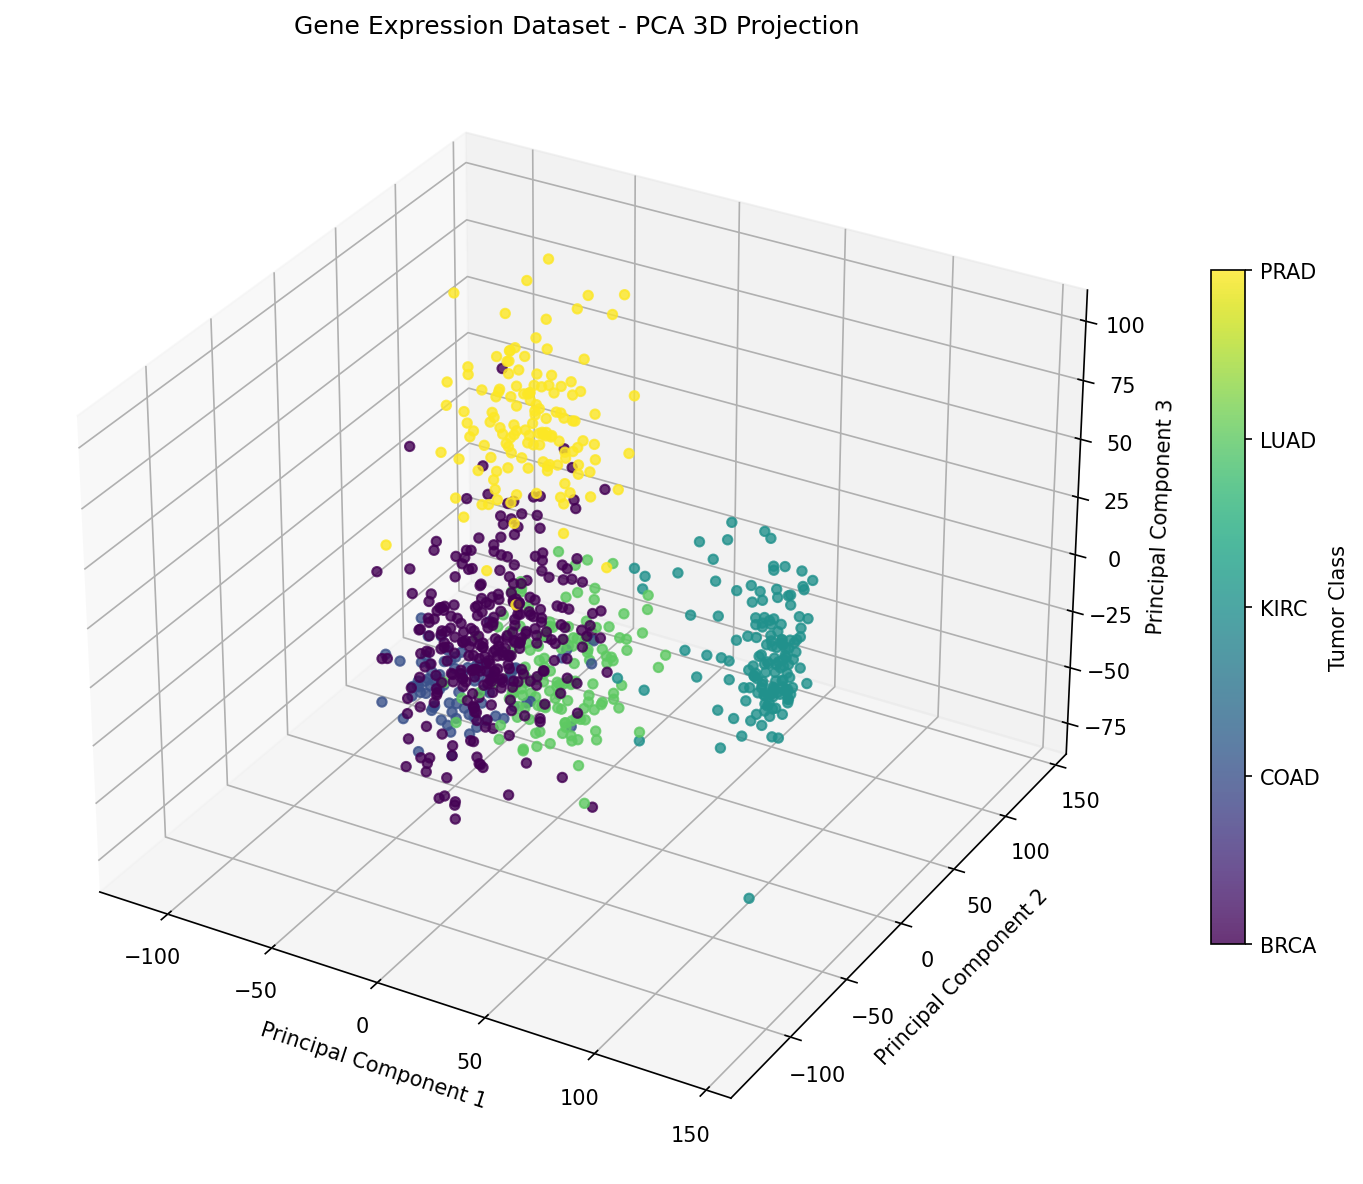

✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\output\figures\phase2_gene_expression\day05_phase2_gene_pca_3d_scatterplot_static.png


In [11]:
# ============================================================
# Cell 10 - PCA 3D Visualization
# ============================================================

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled_all)
pcdf_3d = pd.DataFrame({"PC1": X_pca_3d[:, 0], "PC2": X_pca_3d[:, 1], "PC3": X_pca_3d[:, 2], "class": y.values})
pcdf_3d_path = os.path.join(PHASE2_TABLES_DIR, "day05_phase2_gene_pca_3d_transformed_data.csv")
pcdf_3d.to_csv(pcdf_3d_path, index=False)

print("3D explained variance:", pca_3d.explained_variance_ratio_)
print("Total 3D explained variance:", pca_3d.explained_variance_ratio_.sum())
display(pcdf_3d.head())

fig = plt.figure(figsize=(10, 8), dpi=150)
ax = fig.add_subplot(111, projection="3d")
class_codes_3d = le_plot.transform(pcdf_3d["class"])
scatter = ax.scatter(pcdf_3d["PC1"], pcdf_3d["PC2"], pcdf_3d["PC3"], c=class_codes_3d, alpha=0.80)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("Gene Expression Dataset - PCA 3D Projection")
cbar = fig.colorbar(scatter, ax=ax, shrink=0.6)
cbar.set_label("Tumor Class")
cbar.set_ticks(range(len(le_plot.classes_)))
cbar.set_ticklabels(le_plot.classes_)
plt.tight_layout()
pca_3d_plot_path = os.path.join(PHASE2_FIGURES_DIR, "day05_phase2_gene_pca_3d_scatterplot_static.png")
plt.savefig(pca_3d_plot_path, dpi=300)
plt.show()
print("✅ Saved:", pca_3d_plot_path)

In [12]:
# ============================================================
# Cell 11 - Train/Test Split and Label Encoding
# ============================================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Classes:")
for code, cls in enumerate(label_encoder.classes_):
    print(code, "=", cls)

class_min_count = pd.Series(y_encoded).value_counts().min()
stratify_arg = y_encoded if class_min_count >= 2 else None
print("Using stratified split:", stratify_arg is not None)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=stratify_arg
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Classes:
0 = BRCA
1 = COAD
2 = KIRC
3 = LUAD
4 = PRAD
Using stratified split: True
X_train shape: (640, 20531)
X_test shape: (161, 20531)


In [13]:
# ============================================================
# Cell 12 - Logistic Regression in Original Feature Space
# ============================================================

scaler_model = StandardScaler()
X_train_scaled = scaler_model.fit_transform(X_train)
X_test_scaled = scaler_model.transform(X_test)

logreg_original = LogisticRegression(max_iter=5000, solver="lbfgs")
start_time = time.time()
logreg_original.fit(X_train_scaled, y_train)
training_time_original = time.time() - start_time

y_pred_original = logreg_original.predict(X_test_scaled)
accuracy_original = accuracy_score(y_test, y_pred_original)
print("Original feature space accuracy:", accuracy_original)
print("Original feature space training time:", training_time_original)
print("\nClassification Report - Original Feature Space:")
print(classification_report(y_test, y_pred_original, target_names=label_encoder.classes_))

cm_original = confusion_matrix(y_test, y_pred_original)
cm_original_df = pd.DataFrame(cm_original, index=label_encoder.classes_, columns=label_encoder.classes_)
display(cm_original_df)
cm_original_path = os.path.join(PHASE2_TABLES_DIR, "day05_phase2_gene_confusion_matrix_original.csv")
cm_original_df.to_csv(cm_original_path)
print("✅ Saved:", cm_original_path)

Original feature space accuracy: 0.9813664596273292
Original feature space training time: 0.39223766326904297

Classification Report - Original Feature Space:
              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       0.94      0.94      0.94        16
        KIRC       1.00      1.00      1.00        30
        LUAD       0.96      0.93      0.95        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.98       161
   macro avg       0.98      0.97      0.97       161
weighted avg       0.98      0.98      0.98       161



,BRCA,COAD,KIRC,LUAD,PRAD
BRCA,60,0,0,0,0
COAD,0,15,0,1,0
KIRC,0,0,30,0,0
LUAD,1,1,0,26,0
PRAD,0,0,0,0,27


✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\output\tables\phase2_gene_expression\day05_phase2_gene_confusion_matrix_original.csv


In [14]:
# ============================================================
# Cell 13 - Logistic Regression in PCA Space
# ============================================================

pca_model = PCA(n_components=0.95)
start_pca_time = time.time()
X_train_pca = pca_model.fit_transform(X_train_scaled)
X_test_pca = pca_model.transform(X_test_scaled)
pca_transform_time = time.time() - start_pca_time
n_components_95_train = pca_model.n_components_

print("Components selected for 95% variance on training data:", n_components_95_train)
print("PCA transform time:", pca_transform_time)

logreg_pca = LogisticRegression(max_iter=5000, solver="lbfgs")
start_time = time.time()
logreg_pca.fit(X_train_pca, y_train)
training_time_pca = time.time() - start_time

y_pred_pca = logreg_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print("PCA feature space accuracy:", accuracy_pca)
print("PCA feature space training time:", training_time_pca)
print("\nClassification Report - PCA Feature Space:")
print(classification_report(y_test, y_pred_pca, target_names=label_encoder.classes_))

cm_pca = confusion_matrix(y_test, y_pred_pca)
cm_pca_df = pd.DataFrame(cm_pca, index=label_encoder.classes_, columns=label_encoder.classes_)
display(cm_pca_df)
cm_pca_path = os.path.join(PHASE2_TABLES_DIR, "day05_phase2_gene_confusion_matrix_pca.csv")
cm_pca_df.to_csv(cm_pca_path)
print("✅ Saved:", cm_pca_path)

Components selected for 95% variance on training data: 434
PCA transform time: 1.9063963890075684
PCA feature space accuracy: 1.0
PCA feature space training time: 0.025206327438354492

Classification Report - PCA Feature Space:
              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      1.00      1.00        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



,BRCA,COAD,KIRC,LUAD,PRAD
BRCA,60,0,0,0,0
COAD,0,16,0,0,0
KIRC,0,0,30,0,0
LUAD,0,0,0,28,0
PRAD,0,0,0,0,27


✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\output\tables\phase2_gene_expression\day05_phase2_gene_confusion_matrix_pca.csv


In [15]:
# ============================================================
# Cell 14 - Model Comparison Table
# ============================================================

comparison_df = pd.DataFrame({
    "model": ["Logistic Regression - Original Features", "Logistic Regression - PCA 95% Variance"],
    "number_of_features_used": [X_train_scaled.shape[1], X_train_pca.shape[1]],
    "accuracy": [accuracy_original, accuracy_pca],
    "training_time_seconds": [training_time_original, training_time_pca],
    "pca_transform_time_seconds": [0.0, pca_transform_time]
})
display(comparison_df)
comparison_path = os.path.join(PHASE2_TABLES_DIR, "day05_phase2_gene_model_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)
print("✅ Saved:", comparison_path)

,model,number_of_features_used,accuracy,training_time_seconds,pca_transform_time_seconds
0,Logistic Regression - Original Features,20531,0.981366,0.392238,0.000000
1,Logistic Regression - PCA 95% Variance,434,1.000000,0.025206,1.906396


✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\output\tables\phase2_gene_expression\day05_phase2_gene_model_comparison.csv


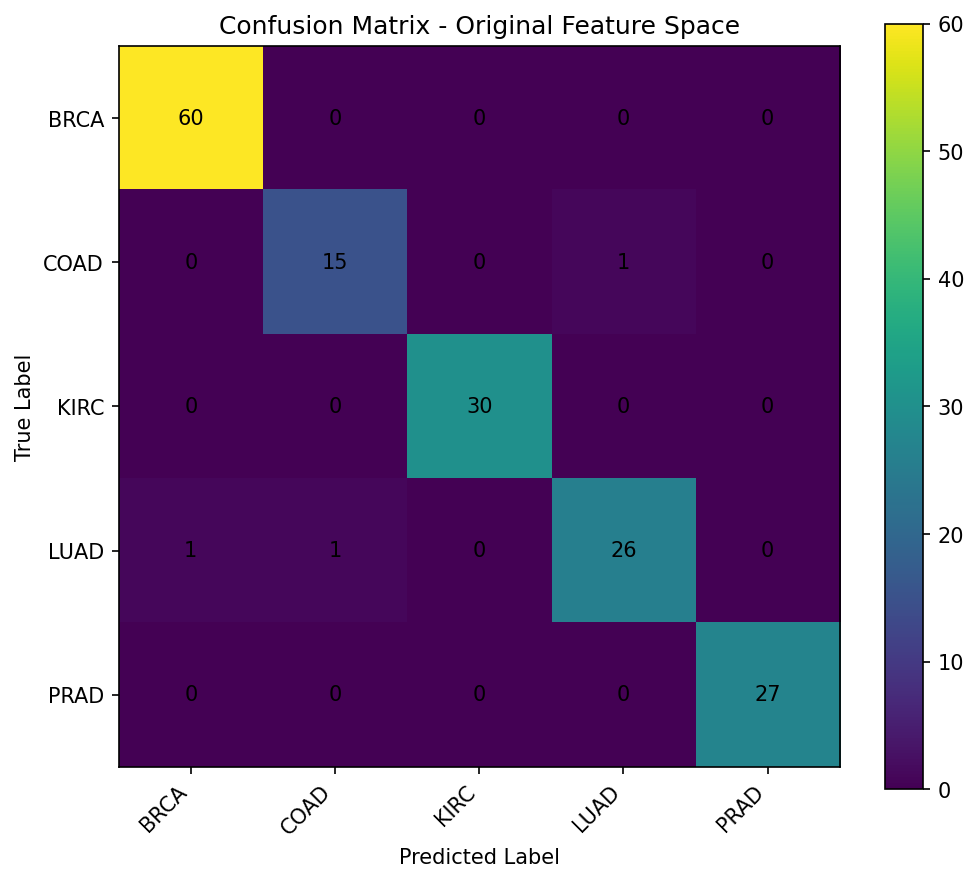

✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\output\figures\phase2_gene_expression\day05_phase2_gene_confusion_matrix_original.png


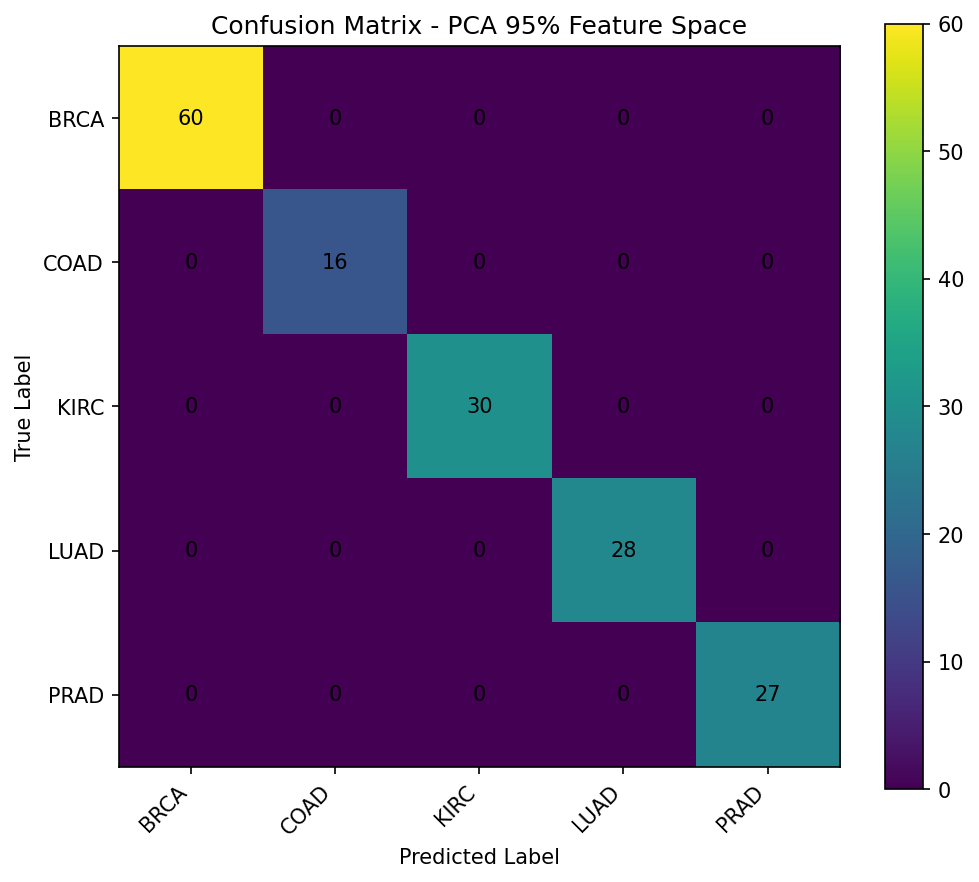

✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\output\figures\phase2_gene_expression\day05_phase2_gene_confusion_matrix_pca.png


In [16]:
# ============================================================
# Cell 15 - Confusion Matrix Plots
# ============================================================

def plot_confusion_matrix(cm, labels, title, save_path):
    plt.figure(figsize=(7, 6), dpi=150)
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha="right")
    plt.yticks(ticks, labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print("✅ Saved:", save_path)

plot_confusion_matrix(cm_original, label_encoder.classes_, "Confusion Matrix - Original Feature Space", os.path.join(PHASE2_FIGURES_DIR, "day05_phase2_gene_confusion_matrix_original.png"))
plot_confusion_matrix(cm_pca, label_encoder.classes_, "Confusion Matrix - PCA 95% Feature Space", os.path.join(PHASE2_FIGURES_DIR, "day05_phase2_gene_confusion_matrix_pca.png"))

In [17]:
# ============================================================
# Cell 16 - PCA Loadings for PC1 and PC2
# ============================================================

loadings = pd.DataFrame(pca_2d.components_.T, index=feature_names, columns=["PC1_loading", "PC2_loading"])
loadings["abs_PC1_loading"] = loadings["PC1_loading"].abs()
loadings["abs_PC2_loading"] = loadings["PC2_loading"].abs()

top_pc1 = loadings.sort_values("abs_PC1_loading", ascending=False).head(30)
top_pc2 = loadings.sort_values("abs_PC2_loading", ascending=False).head(30)

display(top_pc1.head(10))
display(top_pc2.head(10))

top_pc1_path = os.path.join(PHASE2_TABLES_DIR, "day05_phase2_gene_top30_pc1_loadings.csv")
top_pc2_path = os.path.join(PHASE2_TABLES_DIR, "day05_phase2_gene_top30_pc2_loadings.csv")
top_pc1.to_csv(top_pc1_path)
top_pc2.to_csv(top_pc2_path)
print("✅ Saved:", top_pc1_path)
print("✅ Saved:", top_pc2_path)

,PC1_loading,PC2_loading,abs_PC1_loading,abs_PC2_loading
gene_19862,0.019002,-0.001658,0.019002,0.001658
gene_17360,0.018985,0.003355,0.018985,0.003355
gene_13489,0.018966,0.001702,0.018966,0.001702
gene_15158,0.018777,-0.001318,0.018777,0.001318
gene_7031,0.018740,0.001457,0.018740,0.001457
gene_7019,0.018657,0.003041,0.018657,0.003041
gene_10788,0.018629,0.001360,0.018629,0.001360
gene_13507,-0.018624,-0.004405,0.018624,0.004405
gene_6543,0.018595,0.002365,0.018595,0.002365
gene_2288,-0.018592,-0.005370,0.018592,0.005370


,PC1_loading,PC2_loading,abs_PC1_loading,abs_PC2_loading
gene_3612,0.004777,-0.020273,0.004777,0.020273
gene_1222,-0.005628,0.019863,0.005628,0.019863
gene_14699,0.001909,-0.019862,0.001909,0.019862
gene_1010,-0.003063,0.019829,0.003063,0.019829
gene_19498,0.002897,0.019505,0.002897,0.019505
gene_1113,0.003745,-0.019409,0.003745,0.019409
gene_3603,0.004092,-0.019346,0.004092,0.019346
gene_364,-0.002515,-0.019225,0.002515,0.019225
gene_11153,-0.006064,0.019222,0.006064,0.019222
gene_19866,-0.000115,0.019133,0.000115,0.019133


✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\output\tables\phase2_gene_expression\day05_phase2_gene_top30_pc1_loadings.csv
✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\output\tables\phase2_gene_expression\day05_phase2_gene_top30_pc2_loadings.csv


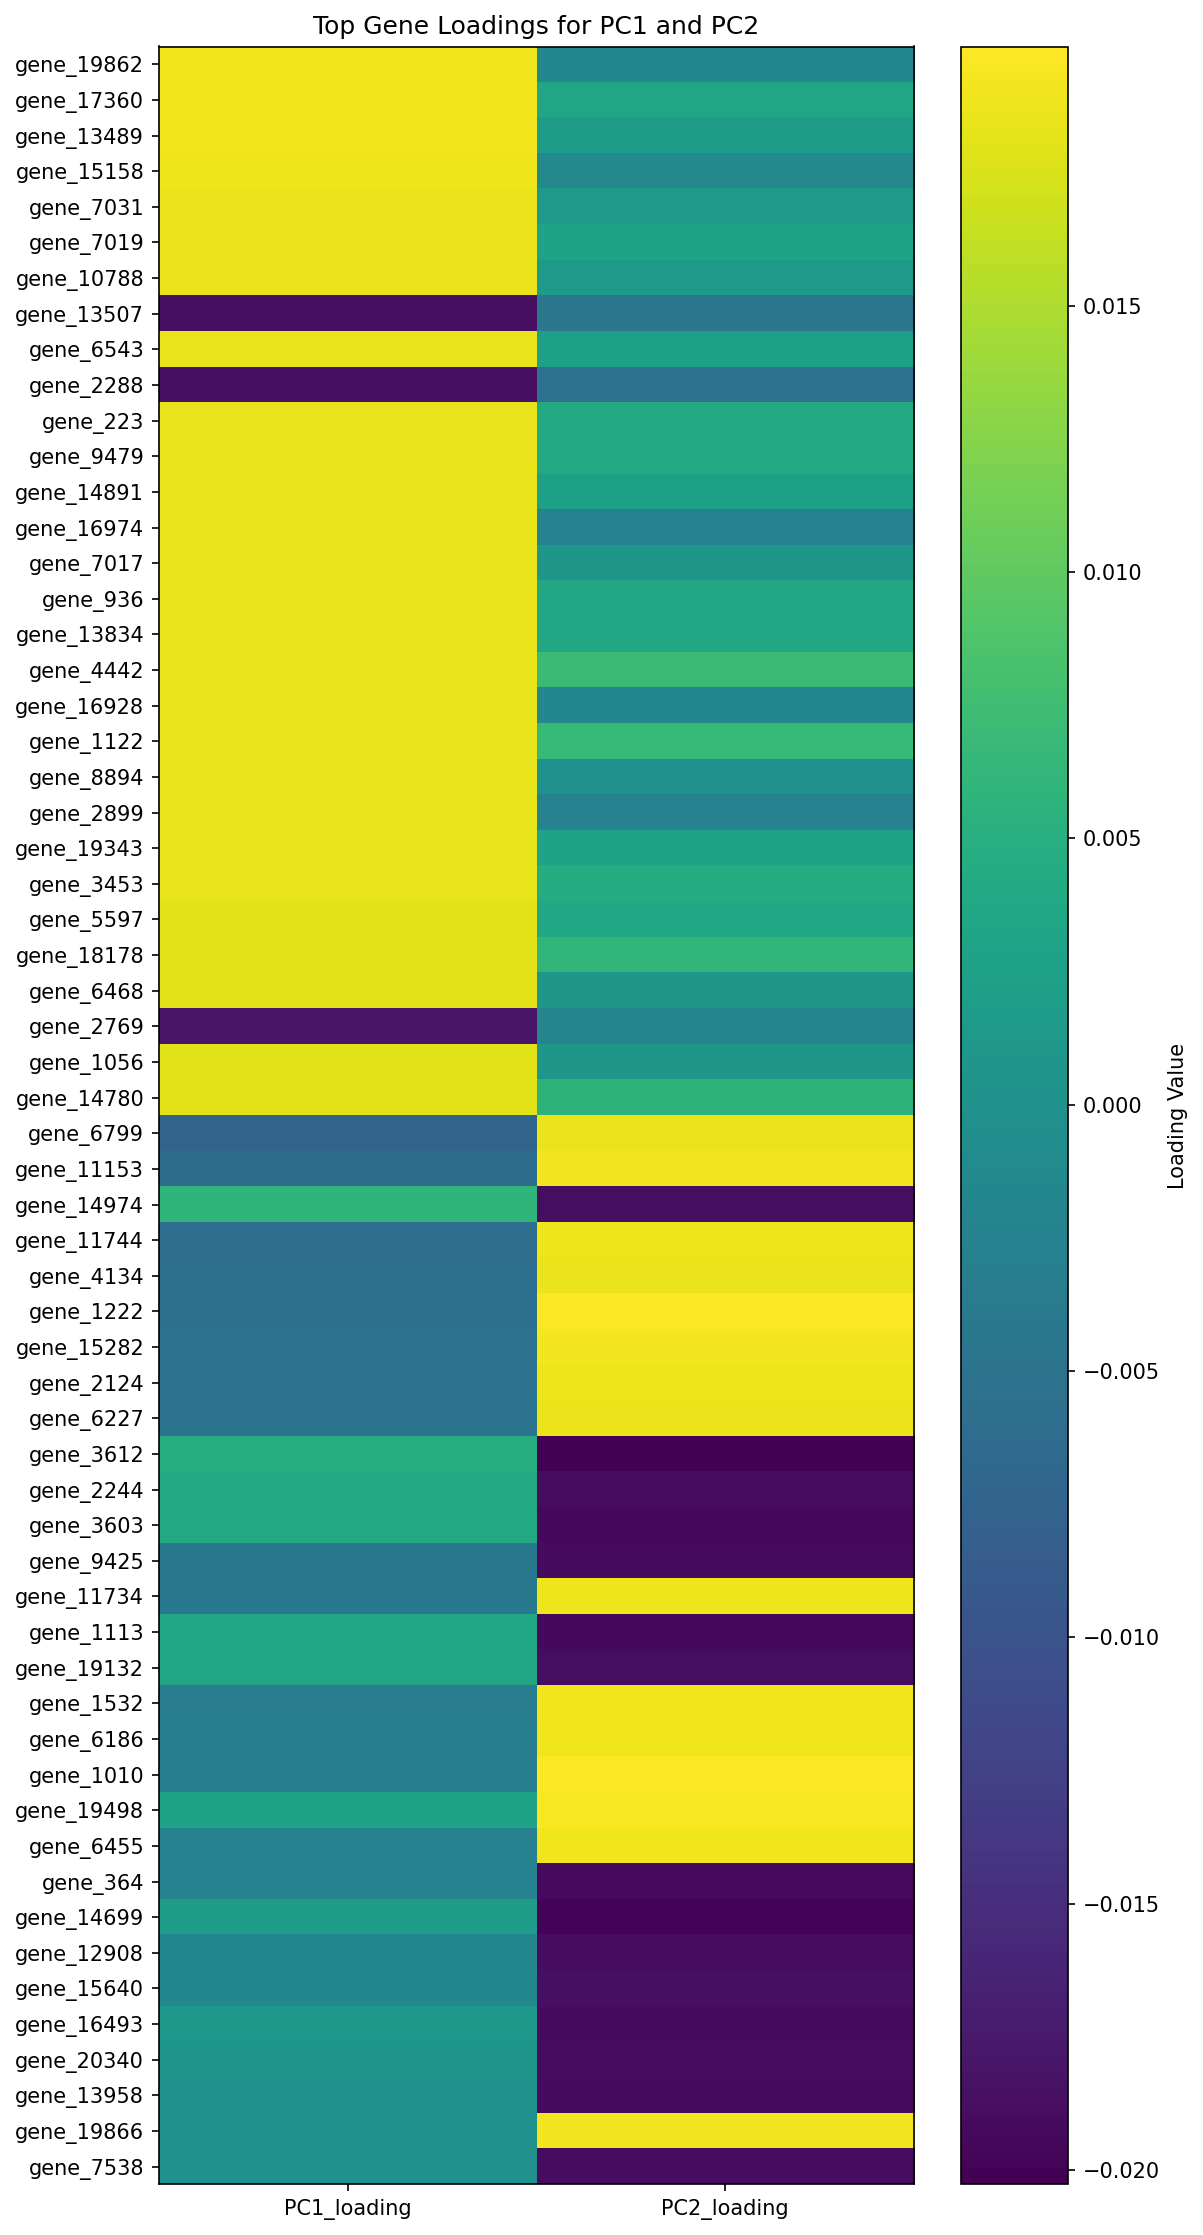

✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\output\figures\phase2_gene_expression\day05_phase2_gene_top_loadings_heatmap.png


In [18]:
# ============================================================
# Cell 17 - Heatmap of Top PCA Loadings
# ============================================================

top_genes = list(dict.fromkeys(top_pc1.index.tolist() + top_pc2.index.tolist()))
loadings_heatmap_df = loadings.loc[top_genes, ["PC1_loading", "PC2_loading"]]
loadings_heatmap_df = loadings_heatmap_df.reindex(loadings_heatmap_df["PC1_loading"].abs().sort_values(ascending=False).index)

plt.figure(figsize=(8, max(8, len(loadings_heatmap_df) * 0.25)), dpi=150)
plt.imshow(loadings_heatmap_df.values, aspect="auto")
plt.colorbar(label="Loading Value")
plt.xticks(np.arange(loadings_heatmap_df.shape[1]), loadings_heatmap_df.columns)
plt.yticks(np.arange(loadings_heatmap_df.shape[0]), loadings_heatmap_df.index)
plt.title("Top Gene Loadings for PC1 and PC2")
plt.tight_layout()
loadings_heatmap_path = os.path.join(PHASE2_FIGURES_DIR, "day05_phase2_gene_top_loadings_heatmap.png")
plt.savefig(loadings_heatmap_path, dpi=300)
plt.show()
print("✅ Saved:", loadings_heatmap_path)

In [19]:
# ============================================================
# Cell 18 - Automatic Summary
# ============================================================

summary = {
    "Number of samples": X.shape[0],
    "Number of original gene features": X.shape[1],
    "Number of classes": y.nunique(),
    "Components for 85% variance": n_85,
    "Components for 90% variance": n_90,
    "Components for 95% variance": n_95,
    "2D explained variance (%)": round(float(pca_2d.explained_variance_ratio_.sum() * 100), 2),
    "3D explained variance (%)": round(float(pca_3d.explained_variance_ratio_.sum() * 100), 2),
    "Original Logistic Regression accuracy": round(float(accuracy_original), 4),
    "PCA Logistic Regression accuracy": round(float(accuracy_pca), 4),
    "Original training time seconds": round(float(training_time_original), 4),
    "PCA training time seconds": round(float(training_time_pca), 4),
    "PCA 95% components in train split": n_components_95_train,
    "Top PC1 genes": ", ".join(top_pc1.head(10).index.tolist()),
    "Top PC2 genes": ", ".join(top_pc2.head(10).index.tolist())
}
summary_df = pd.DataFrame(list(summary.items()), columns=["item", "value"])
display(summary_df)
summary_path = os.path.join(PHASE2_TABLES_DIR, "day05_phase2_gene_summary.csv")
summary_df.to_csv(summary_path, index=False)
print("✅ Saved:", summary_path)

,item,value
0,Number of samples,801
1,Number of original gene features,20531
2,Number of classes,5
3,Components for 85% variance,262
4,Components for 90% variance,373
5,Components for 95% variance,530
6,2D explained variance (%),19.29
7,3D explained variance (%),27.1
8,Original Logistic Regression accuracy,0.9814
9,PCA Logistic Regression accuracy,1.0


✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\dimensionality-reduction-pca-wine\output\tables\phase2_gene_expression\day05_phase2_gene_summary.csv


In [20]:
# ============================================================
# Cell 19 - Final Check: List Created Files
# ============================================================

print("✅ Tables created:")
for file in sorted(os.listdir(PHASE2_TABLES_DIR)):
    print(" -", file)
print("\n✅ Figures created:")
for file in sorted(os.listdir(PHASE2_FIGURES_DIR)):
    print(" -", file)

✅ Tables created:
 - day05_phase2_gene_basic_info.csv
 - day05_phase2_gene_class_counts.csv
 - day05_phase2_gene_confusion_matrix_original.csv
 - day05_phase2_gene_confusion_matrix_pca.csv
 - day05_phase2_gene_model_comparison.csv
 - day05_phase2_gene_pca_2d_transformed_data.csv
 - day05_phase2_gene_pca_3d_transformed_data.csv
 - day05_phase2_gene_pca_full_explained_variance.csv
 - day05_phase2_gene_summary.csv
 - day05_phase2_gene_top30_pc1_loadings.csv
 - day05_phase2_gene_top30_pc2_loadings.csv

✅ Figures created:
 - day05_phase2_gene_class_distribution.png
 - day05_phase2_gene_confusion_matrix_original.png
 - day05_phase2_gene_confusion_matrix_pca.png
 - day05_phase2_gene_cumulative_explained_variance.png
 - day05_phase2_gene_pca_2d_scatterplot.png
 - day05_phase2_gene_pca_3d_scatterplot_static.png
 - day05_phase2_gene_scree_plot.png
 - day05_phase2_gene_top_loadings_heatmap.png


# End of Phase 2

Send these output files after running:

```text
output/tables/phase2_gene_expression/day05_phase2_gene_summary.csv
output/tables/phase2_gene_expression/day05_phase2_gene_pca_full_explained_variance.csv
output/tables/phase2_gene_expression/day05_phase2_gene_model_comparison.csv
output/tables/phase2_gene_expression/day05_phase2_gene_top30_pc1_loadings.csv
output/tables/phase2_gene_expression/day05_phase2_gene_top30_pc2_loadings.csv

output/figures/phase2_gene_expression/day05_phase2_gene_scree_plot.png
output/figures/phase2_gene_expression/day05_phase2_gene_cumulative_explained_variance.png
output/figures/phase2_gene_expression/day05_phase2_gene_pca_2d_scatterplot.png
output/figures/phase2_gene_expression/day05_phase2_gene_pca_3d_scatterplot_static.png
output/figures/phase2_gene_expression/day05_phase2_gene_top_loadings_heatmap.png
output/figures/phase2_gene_expression/day05_phase2_gene_confusion_matrix_original.png
output/figures/phase2_gene_expression/day05_phase2_gene_confusion_matrix_pca.png
```